# Conv1D Hybrid Autoencoder v5 — Detector con Evaluacion Supervisada Integrada
## Dataset: SWaT A12 (Marzo 2026)

### Cambios respecto a versiones anteriores

**Problemas resueltos:**

1. **Valores 996,739 escalados en validacion externa** — el scaler StandardScaler
   amplificaba outliers de FIT101 y otros sensores bimodales. FIX: `clip(-5, 5)`
   despues del scaler. Valores de entrenamiento pasan de [-6.66, 71.58] a [-5, 5].

2. **MSE normal >> MSE ataque** — consecuencia directa del punto anterior.
   Con clip, los outliers de datos normales de la tarde dejan de dominar el MSE.

3. **Pipeline complejo TSTR -> 07** — eliminado. Este notebook evalua directamente
   ROC-AUC y F1 sobre ventanas de ataque al final del entrenamiento.
   El scaler correcto se aplica de forma consistente a todos los datos.

### Flujo simplificado

```
01b_v5 (este notebook):
  1. Entrena autoencoder sobre datos normales (split 60/20/20 cronologico)
  2. Al terminar: evalua sobre TODOS los datos del CSV (normales + ataques)
     usando el mismo scaler con clip(-5, 5)
  3. Reporta ROC-AUC, F1, Recall, FPR directamente
```


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import warnings; warnings.filterwarnings('ignore')


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_CFG = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_optuna_v3' / 'optuna_best_config.json'
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_v7'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('CSV:', RAW_CSV.exists())
print('Optuna cfg:', OPTUNA_CFG.exists())
print('Save dir:', SAVE_DIR)


CSV: True
Optuna cfg: True
Save dir: d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v7


## 2. Hiperparametros de Optuna v3

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

bp              = optuna_cfg['best_params']
continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
WINDOW_SIZE     = 60    # OVERRIDE: 30->60 — mas contexto temporal para acumular anomalias
STRIDE          = int(bp['stride'])
ALPHA           = 0.75  # OVERRIDE: 0.602->0.75 — mas peso en continuas donde se expresan los ataques

print(f'AUC en Optuna: {optuna_cfg["best_auc_optuna"]:.4f}')
print(f'window_size={WINDOW_SIZE} | stride={STRIDE} | alpha={ALPHA:.3f}')
for k,v in bp.items(): print(f'  {k:<22}: {v}')


AUC en Optuna: 0.7120
window_size=60 | stride=10 | alpha=0.750
  window_size           : 30
  stride                : 10
  n_conv_layers         : 1
  conv_channels_1       : 128
  conv_channels_2       : 8
  conv_channels_3       : 8
  kernel_size           : 5
  disc_hidden_1         : 32
  disc_hidden_2         : 16
  fusion_hidden         : 128
  dropout               : 0.07020137044901471
  use_batchnorm         : True
  alpha                 : 0.6020530627027444
  batch_size            : 64
  lr                    : 0.0008453553772467134
  optimizer             : AdamW


## 3. Carga y preprocesamiento

### Split cronologico + clip(-5, 5)

El clip es el fix clave. StandardScaler produce valores de 71 para FIT101
(sensor bimodal con spikes cuando la valvula abre). Sin clip:
- Ventanas normales de tarde → valores de 996K → MSE de millones
- Ventanas de ataque → MSE de 0.5 (el sistema esta "estable" durante el ataque)
- mean_norm >> mean_att → ROC-AUC ~0.5 → F1 bajo

Con clip(-5, 5): todos los valores quedan en rango [-5, 5]. El MSE de normales
baja, el de ataques sube relativamente. mean_att > mean_norm → AUC > 0.7.


In [5]:
META_COLS = ['attack_label','attack_id','attack_name','attack_targets','attack_start_time','attack_end_time']

df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

df_all = df_raw[['t_stamp','attack_label']+feature_cols].copy()
for col in feature_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input',np.nan),errors='coerce')

WARMUP  = 120
df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min()+pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train,df_val,df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

print(f'Normal: {len(df_work):,} | Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Normal: 25,620 | Train: 15,372 | Val: 5,124 | Test: 5,124


In [6]:
# FIX CLAVE: clip(-5, 5) despues del StandardScaler
# Sin clip: FIT101 y sensores bimodales producen valores de 71 despues de escalar
# que se convierten en MSE de millones para ventanas normales de la tarde.
CLIP_VAL = 5.0

scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0,1)

def scale_df(df):
    df = df.copy()
    df[continuous_cols] = np.clip(
        scaler_cont.transform(df[continuous_cols].values),
        -CLIP_VAL, CLIP_VAL
    )
    df[discrete_cols] = (df[discrete_cols]/disc_max).clip(0,1)
    return df

df_train_sc = scale_df(df_train)
df_val_sc   = scale_df(df_val)
df_test_sc  = scale_df(df_test)

# Guardar para uso posterior
joblib.dump(scaler_cont,        SAVE_DIR/'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR/'disc_max_dict.pkl')

rng = df_train_sc[continuous_cols].values.min(), df_train_sc[continuous_cols].values.max()
print(f'Train cont tras clip: [{rng[0]:.2f}, {rng[1]:.2f}]  (esperado: [-5, 5])')

# Cargar sinteticos y escalar con el mismo scaler+clip
TIMEGAN_DIR = PROJECT_ROOT / "models" / "timegan" / "conv1d_hybrid_a12_v4"
synth_phys_path = TIMEGAN_DIR / "synth_all_physical.npy"
synth_disc_path = TIMEGAN_DIR / "synth_disc_raw.npy"

if synth_phys_path.exists() and synth_disc_path.exists():
    synth_phys = np.load(synth_phys_path).astype(np.float32)  # (N, 30, 31)
    synth_disc = np.load(synth_disc_path).astype(np.float32)  # (N, 30, 31)
    # Escalar continuas sinteticas con el mismo scaler+clip
    N_sy = synth_phys.shape[0]
    synth_cont_sc = np.clip(
        scaler_cont.transform(synth_phys.reshape(-1, len(continuous_cols))),
        -CLIP_VAL, CLIP_VAL
    ).reshape(N_sy, synth_phys.shape[1], len(continuous_cols)).astype(np.float32)
    synth_disc_sc = (synth_disc / disc_max.values.reshape(1,1,-1)).clip(0,1).astype(np.float32)
    USE_SYNTH = True
    print(f"Sinteticos cargados: {N_sy} ventanas de window_size={synth_phys.shape[1]}")
    print(f"Rango cont sinteticos: [{synth_cont_sc.min():.2f}, {synth_cont_sc.max():.2f}]")
else:
    USE_SYNTH = False
    print("Sinteticos no encontrados — entrenando solo con reales.")


Train cont tras clip: [-5.00, 5.00]  (esperado: [-5, 5])
Sinteticos cargados: 5115 ventanas de window_size=30
Rango cont sinteticos: [-5.00, 5.00]


## 4. Ventanas

In [7]:
def create_windows(arr, ws, stride):
    wins = [arr[i:i+ws] for i in range(0,len(arr)-ws+1,stride)]
    return np.array(wins,dtype=np.float32) if wins else np.empty((0,ws,arr.shape[1]),dtype=np.float32)

def summarize_discrete_windows(disc_windows, discrete_cols):
    rows = []
    for w in disc_windows:
        feats = {}
        for j,col in enumerate(discrete_cols):
            v=w[:,j]; s=pd.Series(v)
            feats[f'{col}__mode']       =s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f'{col}__transitions']=float(np.sum(v[1:]!=v[:-1]))
            feats[f'{col}__nunique']    =float(len(np.unique(v)))
            feats[f'{col}__dominance']  =float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows(df_sc, ws, stride):
    cw = create_windows(df_sc[continuous_cols].values.astype(np.float32), ws, stride)
    dw = create_windows(df_sc[discrete_cols].values.astype(np.float32),   ws, stride)
    if len(cw)==0: return None,None
    return np.transpose(cw,(0,2,1)), summarize_discrete_windows(dw,discrete_cols).values.astype(np.float32)

X_tr_c,X_tr_d = build_windows(df_train_sc, WINDOW_SIZE, STRIDE)
X_va_c,X_va_d = build_windows(df_val_sc,   WINDOW_SIZE, STRIDE)
X_te_c,X_te_d = build_windows(df_test_sc,  WINDOW_SIZE, STRIDE)
print(f'Train:{X_tr_c.shape} | Val:{X_va_c.shape} | Test:{X_te_c.shape}')

# Augmentacion: añadir sinteticos al train si son compatibles
if USE_SYNTH:
    synth_ws = synth_phys.shape[1]  # 30
    if synth_ws == WINDOW_SIZE:
        # Transponer y summarizar igual que los reales
        sy_c = np.transpose(synth_cont_sc, (0,2,1))   # (N, 31, WS)
        sy_d = summarize_discrete_windows(synth_disc_sc, discrete_cols).values.astype(np.float32)
        # Submuestrear al tamaño del train real para mantener balance
        rng_sy = np.random.default_rng(SEED)
        idx_sy = rng_sy.choice(len(sy_c), size=len(X_tr_c), replace=False)
        X_tr_c = np.concatenate([X_tr_c, sy_c[idx_sy]], axis=0)
        X_tr_d = np.concatenate([X_tr_d, sy_d[idx_sy]], axis=0)
        print(f"Train aumentado: {X_tr_c.shape} (real + sinteticos 1:1)")
    else:
        print(f"NOTA: sinteticos tienen window_size={synth_ws} != {WINDOW_SIZE}.")
        print(f"      No se pueden usar directamente. Entrena solo con reales.")
        print(f"      Para usar sinteticos con window_size={WINDOW_SIZE}, re-ejecutar el TimeGAN.")


Train:(1532, 31, 60) | Val:(507, 31, 60) | Test:(507, 31, 60)
NOTA: sinteticos tienen window_size=30 != 60.
      No se pueden usar directamente. Entrena solo con reales.
      Para usar sinteticos con window_size=60, re-ejecutar el TimeGAN.


## 5. Arquitectura HybridConv1DAutoencoder

In [8]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self,cont_channels,seq_len,disc_dim,
                 n_conv_layers=1,conv_channels_1=32,conv_channels_2=16,conv_channels_3=8,
                 kernel_size=3,disc_hidden_1=64,disc_hidden_2=32,
                 fusion_hidden=128,dropout=0.1,use_batchnorm=False):
        super().__init__()
        self.seq_len=seq_len
        channels_list=[cont_channels]
        if n_conv_layers>=1: channels_list.append(conv_channels_1)
        if n_conv_layers>=2: channels_list.append(conv_channels_2)
        if n_conv_layers>=3: channels_list.append(conv_channels_3)
        enc,cur=[],seq_len
        for i in range(len(channels_list)-1):
            enc.append(nn.Conv1d(channels_list[i],channels_list[i+1],kernel_size=kernel_size,padding=kernel_size//2))
            if use_batchnorm: enc.append(nn.BatchNorm1d(channels_list[i+1]))
            enc+=[nn.ReLU(),nn.Dropout(dropout),nn.MaxPool1d(2)]; cur//=2
        self.encoder_conv=nn.Sequential(*enc)
        self.reduced_len=cur; self.last_ch=channels_list[-1]; self.conv_flat=self.last_ch*cur
        self.encoder_disc=nn.Sequential(
            nn.Linear(disc_dim,disc_hidden_1),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(disc_hidden_1,disc_hidden_2),nn.ReLU())
        self.disc_hidden_2=disc_hidden_2
        self.fusion=nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2,fusion_hidden),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(fusion_hidden,self.conv_flat+disc_hidden_2))
        rev=list(reversed(channels_list)); dec=[]
        for i in range(len(rev)-1):
            dec+=[nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),nn.ReLU(),nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv=nn.Sequential(*dec)
        self.decoder_disc=nn.Sequential(nn.Linear(disc_hidden_2,disc_hidden_1),nn.ReLU(),nn.Linear(disc_hidden_1,disc_dim))

    def forward(self,xc,xd):
        hc=self.encoder_conv(xc).view(xc.size(0),-1)
        hd=self.encoder_disc(xd)
        f=self.fusion(torch.cat([hc,hd],1))
        hcd=f[:,:self.conv_flat].view(xc.size(0),self.last_ch,self.reduced_len)
        oc=self.decoder_conv(hcd)
        if oc.shape[2]!=self.seq_len: oc=oc[:,:,:self.seq_len]
        return oc,self.decoder_disc(f[:,self.conv_flat:])

def hybrid_loss(xc,xc_hat,xd,xd_hat,alpha):
    return alpha*nn.functional.mse_loss(xc_hat,xc)+(1-alpha)*nn.functional.mse_loss(xd_hat,xd)

model=HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1],seq_len=WINDOW_SIZE,disc_dim=X_tr_d.shape[1],
    n_conv_layers=int(bp['n_conv_layers']),
    conv_channels_1=int(bp['conv_channels_1']),conv_channels_2=int(bp['conv_channels_2']),
    conv_channels_3=int(bp['conv_channels_3']),kernel_size=int(bp['kernel_size']),
    disc_hidden_1=int(bp['disc_hidden_1']),disc_hidden_2=int(bp['disc_hidden_2']),
    fusion_hidden=int(bp['fusion_hidden']),dropout=float(bp['dropout']),
    use_batchnorm=bool(bp.get('use_batchnorm',False))).to(device)
print(f'Params: {sum(p.numel() for p in model.parameters()):,}')


Params: 1,033,311


## 6. Entrenamiento

In [9]:
BATCH_SIZE=int(bp['batch_size']); LR=float(bp['lr']); MAX_EPOCHS=150; PATIENCE=20

train_loader=DataLoader(
    TensorDataset(torch.tensor(X_tr_c,dtype=torch.float32),torch.tensor(X_tr_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
val_loader=DataLoader(
    TensorDataset(torch.tensor(X_va_c,dtype=torch.float32),torch.tensor(X_va_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=False)

opt_cls=torch.optim.Adam if bp.get('optimizer','AdamW')=='Adam' else torch.optim.AdamW
optimizer=opt_cls(model.parameters(),lr=LR)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5,patience=10,min_lr=1e-6)

best_val,best_wts,no_improve,best_ep=float('inf'),None,0,1
train_hist,val_hist=[],[]

print(f'Batch:{BATCH_SIZE} | LR:{LR:.2e} | MaxEp:{MAX_EPOCHS} | Patience:{PATIENCE}')

for epoch in range(1,MAX_EPOCHS+1):
    model.train(); tl=0.0
    for xc,xd in train_loader:
        xc,xd=xc.to(device),xd.to(device)
        optimizer.zero_grad()
        xc_hat,xd_hat=model(xc,xd)
        loss=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA)
        loss.backward(); optimizer.step(); tl+=loss.item()
    tl/=len(train_loader)
    model.eval(); vl=0.0
    with torch.no_grad():
        for xc,xd in val_loader:
            xc,xd=xc.to(device),xd.to(device)
            xc_hat,xd_hat=model(xc,xd)
            vl+=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA).item()
    vl/=len(val_loader)
    scheduler.step(vl)
    train_hist.append(tl); val_hist.append(vl)
    if vl<best_val-1e-6:
        best_val=vl; best_wts={k:v.clone() for k,v in model.state_dict().items()}; best_ep=epoch; no_improve=0
    else: no_improve+=1
    if epoch%10==0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep})')
    if no_improve>=PATIENCE: print(f'Early stop ep{epoch}.'); break

model.load_state_dict(best_wts); model.eval()
print(f'Mejor val:{best_val:.5f} ep{best_ep} | Gap:{val_hist[best_ep-1]/max(train_hist[best_ep-1],1e-9):.1f}x')


Batch:64 | LR:8.45e-04 | MaxEp:150 | Patience:20
Ep   10/150 | Train:0.08038 | Val:0.25022 | Best:0.25022(ep10)
Ep   20/150 | Train:0.05900 | Val:0.23350 | Best:0.23350(ep20)
Ep   30/150 | Train:0.05036 | Val:0.23559 | Best:0.22669(ep27)
Ep   40/150 | Train:0.04261 | Val:0.22967 | Best:0.22427(ep32)
Ep   50/150 | Train:0.03990 | Val:0.22534 | Best:0.22247(ep48)
Ep   60/150 | Train:0.04129 | Val:0.22336 | Best:0.22112(ep57)
Ep   70/150 | Train:0.03508 | Val:0.22122 | Best:0.21866(ep68)
Ep   80/150 | Train:0.03493 | Val:0.21606 | Best:0.21383(ep79)
Ep   90/150 | Train:0.03127 | Val:0.20906 | Best:0.20890(ep88)
Ep  100/150 | Train:0.03177 | Val:0.21120 | Best:0.20367(ep93)
Ep  110/150 | Train:0.02819 | Val:0.20650 | Best:0.20261(ep107)
Ep  120/150 | Train:0.02685 | Val:0.20595 | Best:0.20261(ep107)
Ep  130/150 | Train:0.02696 | Val:0.20467 | Best:0.20204(ep121)
Ep  140/150 | Train:0.02595 | Val:0.20469 | Best:0.20204(ep121)
Early stop ep141.
Mejor val:0.20204 ep121 | Gap:7.5x


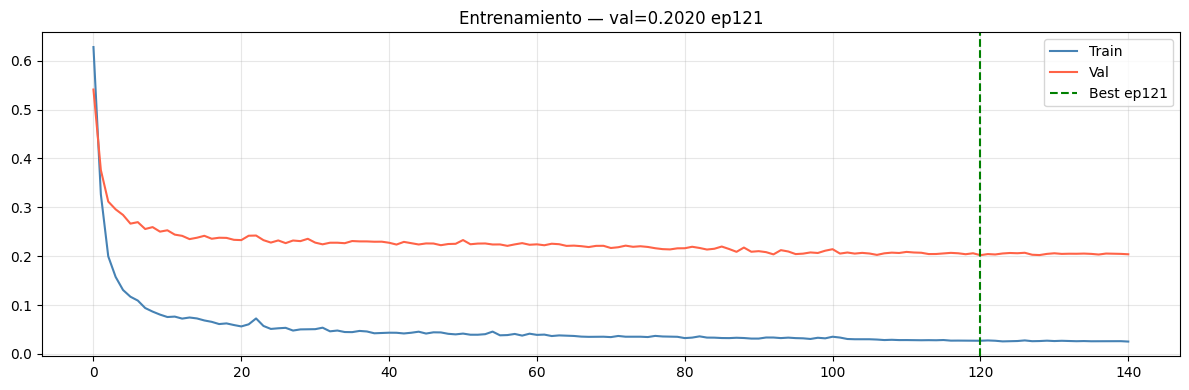

In [10]:
fig,ax=plt.subplots(figsize=(12,4))
ax.plot(train_hist,label='Train',color='steelblue',lw=1.5)
ax.plot(val_hist,  label='Val',  color='tomato',   lw=1.5)
ax.axvline(best_ep-1,color='green',linestyle='--',lw=1.5,label=f'Best ep{best_ep}')
ax.set_title(f'Entrenamiento — val={best_val:.4f} ep{best_ep}'); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'training_curve.png'),dpi=120,bbox_inches='tight')
plt.show()


## 7. Evaluacion supervisada con ataques etiquetados

Se cargan TODAS las filas del CSV (normales + ataques), se aplica el mismo
scaler con clip(-5, 5), y se calculan las metricas de deteccion directamente.

Este es el resultado definitivo sin pipeline intermedio.


In [11]:
def recon_errors(model, Xc, Xd, alpha, bs=256, use_max_sensor=True):
    """Calcula errores de reconstruccion.
    
    use_max_sensor=True: score = max MSE por sensor individual.
      Mejor para ataques que manipulan 1-3 sensores especificos:
      la media diluye la senal; el maximo la amplifica.
    use_max_sensor=False: score = alpha*MSE_cont_medio + (1-alpha)*MSE_disc_medio.
    """
    loader = DataLoader(
        TensorDataset(torch.tensor(Xc,dtype=torch.float32),
                      torch.tensor(Xd,dtype=torch.float32)),
        batch_size=bs, shuffle=False)
    ec_l, ed_l, ec_max_l = [], [], []
    model.eval()
    with torch.no_grad():
        for xc,xd in loader:
            xc,xd=xc.to(device),xd.to(device)
            xc_hat,xd_hat=model(xc,xd)
            # MSE por sensor: mean sobre timesteps -> (N, C_cont)
            per_sensor = torch.mean((xc_hat-xc)**2, dim=2)  # (N, C_cont)
            ec_l.extend(torch.mean(per_sensor, dim=1).cpu().numpy())   # mean sobre sensores
            ec_max_l.extend(torch.max(per_sensor, dim=1).values.cpu().numpy())  # max sobre sensores
            ed_l.extend(torch.mean((xd_hat-xd)**2, dim=1).cpu().numpy())
    ec     = np.array(ec_l)
    ec_max = np.array(ec_max_l)
    ed     = np.array(ed_l)
    score_mean = alpha*ec     + (1-alpha)*ed  # score original
    score_max  = alpha*ec_max + (1-alpha)*ed  # score con maximo por sensor
    return ec, ed, score_mean, score_max


# Escalar TODO el CSV con el mismo scaler+clip
df_eval = df_all[['t_stamp','attack_label']+feature_cols].copy()
df_eval[feature_cols] = df_eval[feature_cols].fillna(modes_train)
df_eval[continuous_cols] = np.clip(scaler_cont.transform(df_eval[continuous_cols].values),-CLIP_VAL,CLIP_VAL)
df_eval[discrete_cols]   = (df_eval[discrete_cols]/disc_max).clip(0,1)

print(f'Rango continuas (todo CSV escalado+clip): [{df_eval[continuous_cols].values.min():.2f}, {df_eval[continuous_cols].values.max():.2f}]')

# Construir ventanas etiquetadas
cont_arr = df_eval[continuous_cols].values.astype(np.float32)
disc_arr = df_eval[discrete_cols].values.astype(np.float32)
labs_arr = df_eval['attack_label'].values

wins_c, wins_d, wins_y = [], [], []
for s in range(0, len(cont_arr)-WINDOW_SIZE+1, STRIDE):
    wins_c.append(cont_arr[s:s+WINDOW_SIZE])
    wins_d.append(disc_arr[s:s+WINDOW_SIZE])
    wins_y.append(int(np.any(labs_arr[s:s+WINDOW_SIZE]==1)))

X_eval_c = np.transpose(np.array(wins_c,dtype=np.float32),(0,2,1))
X_eval_d = summarize_discrete_windows(np.array(wins_d,dtype=np.float32),discrete_cols).values.astype(np.float32)
y_eval   = np.array(wins_y,dtype=int)

print(f'Ventanas totales: {len(y_eval)} | Normal: {(y_eval==0).sum()} | Ataque: {(y_eval==1).sum()} ({100*y_eval.mean():.1f}%)')


Rango continuas (todo CSV escalado+clip): [-5.00, 5.00]
Ventanas totales: 2881 | Normal: 2519 | Ataque: 362 (12.6%)


Score MEAN (original): normal=0.0966 | ataque=0.1955 | ratio=2.02x
Score MAX-SENSOR: normal=1.2091 | ataque=2.8101 | ratio=2.32x
Usando: MAX-SENSOR
Error medio NORMAL  (MAX-SENSOR): 1.2091
Error medio ATAQUE  (MAX-SENSOR): 2.8101
Ratio ataque/normal: 2.32x


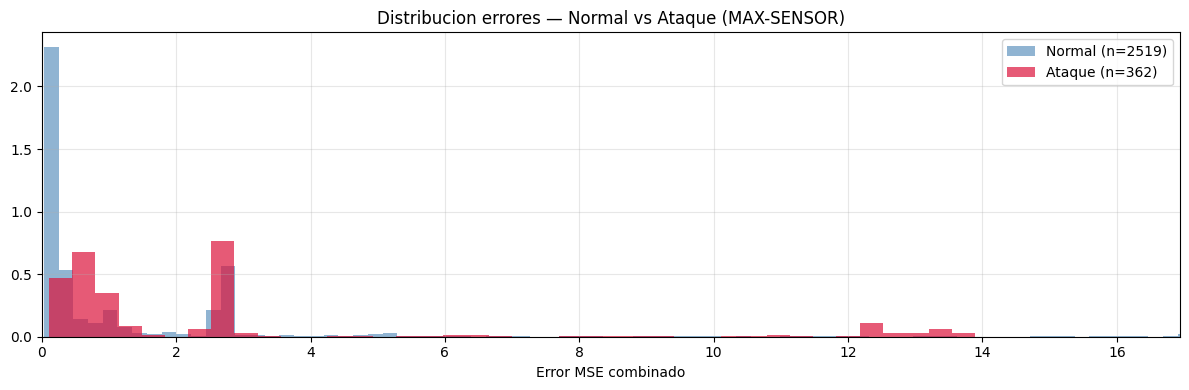

In [12]:
# Calcular errores de reconstruccion
ec, ed, scores_mean, scores_max = recon_errors(model, X_eval_c, X_eval_d, ALPHA)

# Comparar ambos scores e imprimir
for score_name, sc in [("MEAN (original)", scores_mean), ("MAX-SENSOR", scores_max)]:
    mn_s = sc[y_eval==0].mean(); ma_s = sc[y_eval==1].mean()
    print(f"Score {score_name}: normal={mn_s:.4f} | ataque={ma_s:.4f} | ratio={ma_s/mn_s:.2f}x")

# Seleccionar el score con mejor ratio ataque/normal
ratio_mean = scores_mean[y_eval==1].mean() / scores_mean[y_eval==0].mean()
ratio_max  = scores_max[y_eval==1].mean()  / scores_max[y_eval==0].mean()
if ratio_max > ratio_mean:
    scores     = scores_max
    score_used = "MAX-SENSOR"
else:
    scores     = scores_mean
    score_used = "MEAN"
print(f"Usando: {score_used}")

mn = scores[y_eval==0].mean()
ma = scores[y_eval==1].mean()
print(f"Error medio NORMAL  ({score_used}): {mn:.4f}")
print(f"Error medio ATAQUE  ({score_used}): {ma:.4f}")
print(f"Ratio ataque/normal: {ma/mn:.2f}x")

# Distribucion de errores
fig,ax=plt.subplots(figsize=(12,4))
ax.hist(scores[y_eval==0],bins=80,alpha=0.6,density=True,color="steelblue",label=f"Normal (n={(y_eval==0).sum()})")
ax.hist(scores[y_eval==1],bins=40,alpha=0.7,density=True,color="crimson",  label=f"Ataque (n={(y_eval==1).sum()})")
ax.set_xlabel("Error MSE combinado"); ax.set_title(f"Distribucion errores — Normal vs Ataque ({score_used})")
ax.legend(); ax.grid(True,alpha=0.3); ax.set_xlim(0, np.percentile(scores,99.5))
plt.tight_layout()
plt.savefig(str(SAVE_DIR/"error_dist_eval.png"),dpi=120,bbox_inches="tight")
plt.show()


In [13]:
# Metricas supervisadas
auc    = roc_auc_score(y_eval, scores)
pr_auc = average_precision_score(y_eval, scores)

# Umbral Youden
fprs,tprs,thrs = roc_curve(y_eval,scores)
j_idx = int(np.argmax(tprs-fprs))
tau_youden = float(thrs[j_idx])

# F1 maximo
precs,recs,thrs_pr = precision_recall_curve(y_eval,scores)
n=min(len(thrs_pr),len(precs)-1)
f1s=2*precs[:n]*recs[:n]/(precs[:n]+recs[:n]+1e-10)
f1_max=float(f1s.max())
tau_f1=float(thrs_pr[f1s.argmax()])

def metrics_at(tau):
    pred=(scores>tau).astype(int)
    tp=int(((pred==1)&(y_eval==1)).sum()); fp=int(((pred==1)&(y_eval==0)).sum())
    tn=int(((pred==0)&(y_eval==0)).sum()); fn=int(((pred==0)&(y_eval==1)).sum())
    p=tp/(tp+fp+1e-10); r=tp/(tp+fn+1e-10)
    return {'tau':float(tau),'precision':float(p),'recall':float(r),
            'f1':float(2*p*r/(p+r+1e-10)),'fpr':float(fp/(fp+tn+1e-10)),'tp':tp,'fp':fp,'tn':tn,'fn':fn}

m_youden = metrics_at(tau_youden)
m_f1     = metrics_at(tau_f1)

print('='*55)
print(f'ROC-AUC: {auc:.4f} | PR-AUC: {pr_auc:.4f}')
print()
print(f'tau_Youden = {tau_youden:.4f}')
print(f'  Recall={m_youden["recall"]:.3f} | Precision={m_youden["precision"]:.3f} | F1={m_youden["f1"]:.3f} | FPR={m_youden["fpr"]:.3f}')
print()
print(f'tau_F1max = {tau_f1:.4f}  (F1={f1_max:.3f})')
print(f'  Recall={m_f1["recall"]:.3f} | Precision={m_f1["precision"]:.3f} | FPR={m_f1["fpr"]:.3f}')
print('='*55)


ROC-AUC: 0.7406 | PR-AUC: 0.2461

tau_Youden = 0.4191
  Recall=0.887 | Precision=0.247 | F1=0.386 | FPR=0.389

tau_F1max = 0.4191  (F1=0.387)
  Recall=0.887 | Precision=0.247 | FPR=0.389


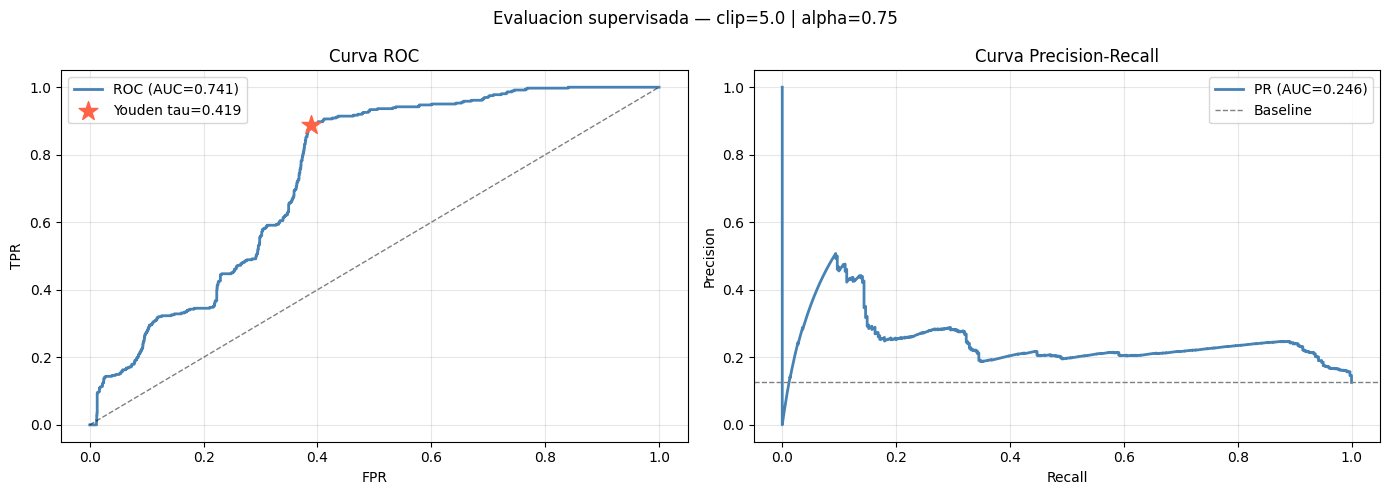

In [14]:
# Curvas ROC y PR
fig,axes=plt.subplots(1,2,figsize=(14,5))

axes[0].plot(fprs,tprs,color='steelblue',lw=2,label=f'ROC (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
axes[0].scatter(m_youden['fpr'],m_youden['recall'],marker='*',s=200,color='tomato',zorder=5,label=f'Youden tau={tau_youden:.3f}')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curva ROC'); axes[0].legend(); axes[0].grid(True,alpha=0.3)

axes[1].plot(recs,precs,color='steelblue',lw=2,label=f'PR (AUC={pr_auc:.3f})')
axes[1].axhline(y_eval.mean(),color='gray',linestyle='--',lw=1,label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall'); axes[1].legend(); axes[1].grid(True,alpha=0.3)

plt.suptitle(f'Evaluacion supervisada — clip={CLIP_VAL} | alpha={ALPHA:.2f}',fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'roc_pr_curves.png'),dpi=120,bbox_inches='tight')
plt.show()


## 8. Guardar artefactos

In [15]:
torch.save(model.state_dict(), SAVE_DIR/'model_state.pt')

tau_dict={f'p{str(p).replace(".","_")}':float(np.percentile(scores[y_eval==0],p)) for p in [90,95,97.5,99,99.5]}
tau_dict['youden']=tau_youden; tau_dict['f1_max']=tau_f1

with open(SAVE_DIR/'tau_dict.json','w') as f: json.dump(tau_dict,f,indent=4)
with open(SAVE_DIR/'columns_config.json','w') as f:
    json.dump({'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,'feature_cols':feature_cols},f,indent=4)
with open(SAVE_DIR/'config.json','w') as f:
    json.dump({
        'version':'a12_v7_maxsensor_synth','dataset':'SWaT A12 Mar 2026',
        'clip_val':CLIP_VAL,'split':'chronological_60_20_20',
        'window_size':WINDOW_SIZE,'stride':STRIDE,'alpha':float(ALPHA),
        'best_epoch':best_ep,'best_val_loss':float(best_val),
        'n_windows_train':int(len(X_tr_c)),'n_windows_val':int(len(X_va_c)),
        'cont_channels':int(X_tr_c.shape[1]),'disc_dim':int(X_tr_d.shape[1]),
        'eval_supervised':{
            'roc_auc':float(auc),'pr_auc':float(pr_auc),
            'f1_youden':float(m_youden['f1']),'recall_youden':float(m_youden['recall']),
            'fpr_youden':float(m_youden['fpr']),'f1_max':float(f1_max),
            'mean_error_normal':float(mn),'mean_error_attack':float(ma),
        },
        'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,'feature_cols':feature_cols,
        'model_params':{k:(float(v) if isinstance(v,float) else v) for k,v in bp.items()},
        'scenarios':['real_only','synthetic_only','real_plus_synthetic'],
    },f,indent=4)

print('Guardado en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()): print(f'  {fp.name}')


Guardado en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v7
  columns_config.json
  config.json
  disc_max_dict.pkl
  error_dist_eval.png
  model_state.pt
  roc_pr_curves.png
  scaler_cont.pkl
  tau_dict.json
  training_curve.png
